1. sample from trained models and test pearson r with and without pre initializing nmf run 1
2. repeat this for each celltype combination to compute specificity (with rmsd against a diagonal matrix and using sinkhon_knopp from scipy)

## Setup environment

### Import modules

In [1]:
import scvi
import scanpy as sc
from pathlib import Path
import numpy as np
import itertools
import pandas as pd
from sklearn.decomposition import non_negative_factorization
from tqdm import tqdm
from typing import Literal, Union
from anndata import AnnData
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_categorical_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/docrep/decorators.py:43: SyntaxWarning: 'param_continuous_covariate_keys' is not a valid key!
  doc = func(self, args[0].__doc__, *args[1:], **kwargs)


### Utils

In [42]:
def cosine_similarity_rows(A: np.array, B: np.array) -> np.array:
    norms_A = np.linalg.norm(A, axis=1)
    norms_B = np.linalg.norm(B, axis=1)
    dot_products = np.einsum('ij,ij->i', A, B)
    return dot_products / (norms_A * norms_B)

def non_negative_factorization_reimplementation(
        X: np.ndarray, 
        W: np.ndarray | None = None, 
        H: None | np.ndarray=None, 
        n_components: Union[None, int]=None, 
        init: Literal["custom"] | None=None,
        update_H: bool=True,
        max_iter: int=200
) -> tuple[np.ndarray, np.ndarray, int]:
    if n_components is None:
        if H is not None:
            n_components = H.shape[0]
        else:
            n_components = min(X.shape)
    if W is None and init != "custom":
        W = np.ones((X.shape[0], n_components))
    if H is None and init != "custom":
        H = np.ones((n_components, X.shape[1]))
    
    for _ in tqdm(range(max_iter)):
        W = (W.T * (H @ X.T) / (H @ H.T @ W.T + 1e-9)).T
        if update_H:
            H = (H * (W.T @ X) / (W.T @ W @ H + 1e-9))
    return W, H, max_iter

def sample_normalized_expression(
    adata: sc.AnnData,
    model: scvi.model._scvi.SCVI
) -> sc.AnnData:
    """
    Returns an AnnData object with counts sampled using a pretrained SCVI Model
    """
    return sc.AnnData(
        X=model.get_normalized_expression().values, 
        obs=adata.obs,
        var=adata.var,
    )

def paired_iterator_sampled_expression(
    n: int,
    a: tuple[sc.AnnData, scvi.model._scvi.SCVI],
    b: tuple[sc.AnnData, scvi.model._scvi.SCVI],
) -> list:
    return list((lambda f, n: lambda a, b: zip(
        [f(*a) for _ in range(n)], 
        [f(*b) for _ in range(n)]))(
        f=sample_normalized_expression,
        n=n
    )(a, b))

def nmf_transfer(
        adata_query: AnnData, 
        adata_reference: AnnData, 
        shared_genes_mask_reference: np.ndarray, 
        gene_filter_mask: np.ndarray | None = None,
        n_components: int | None = None, 
        nmf_func: callable = non_negative_factorization,
        W_init_reference: np.ndarray | None = None,
        H_init_reference: np.ndarray | None = None,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:

    shared_genes = adata_reference[:, shared_genes_mask_reference].var_names

    if gene_filter_mask is None:
        gene_filter_mask = np.ones(len(shared_genes), dtype=bool)

    init_reference = "custom" if W_init_reference is not None or H_init_reference is not None else None

    if W_init_reference is not None:
        W_init_reference = W_init_reference.copy(order="C")

    W, H, _, W_init, H_init = (
        lambda W_init, H_init, _: (
            *nmf_func(
                adata_query[:, shared_genes][:, gene_filter_mask].X.toarray(), 
                H=H_init[:, gene_filter_mask], 
                init="custom", 
                update_H=False
            ), 
            W_init, 
            H_init)
        )(
            *nmf_func(
                adata_reference[:, shared_genes_mask_reference].X.toarray(), 
                init=init_reference, 
                W=W_init_reference, 
                H=H_init_reference, 
                n_components=n_components
            )
        )
    return W, H, W_init, H_init

def benchmark_reconstruction(count_matrix: np.array, count_matrix_reconstructed: np.array) -> None:
    log_original = np.log1p(count_matrix)
    log_reconstructed = np.log1p(count_matrix_reconstructed)

    row_means_original = count_matrix.mean(axis=1)
    row_means_reconstructed = count_matrix_reconstructed.mean(axis=1)
    col_means_original = count_matrix.mean(axis=0)
    col_means_reconstructed = count_matrix_reconstructed.mean(axis=0)

    fig, axes = plt.subplots(3, 2, figsize=(6, 8))

    sns.heatmap(log_original, ax=axes[0, 0], cmap="magma", cbar=True)
    axes[0, 0].set_title("Log Transformed \n Original Count Matrix")

    sns.heatmap(log_reconstructed, ax=axes[0, 1], cmap="magma", cbar=True)
    axes[0, 1].set_title("Log Transformed \n Reconstructed Count Matrix")

    pearson_row, _ = pearsonr(row_means_original, row_means_reconstructed)
    axes[1, 0].scatter(row_means_original, row_means_reconstructed, alpha=0.5, color="black")
    axes[1, 0].plot([row_means_original.min(), row_means_original.max()], 
                    [row_means_original.min(), row_means_original.max()], 
                    linestyle="dashed", color="red")
    axes[1, 0].set_xlabel("Cell Mean (Original)")
    axes[1, 0].set_ylabel("Cell Mean (Reconstructed)")
    axes[1, 0].set_title("Cell-wise Mean Comparison")
    axes[1, 0].text(0.05, 0.9, f"Pearson r = {pearson_row:.2f}", 
                    transform=axes[1, 0].transAxes, fontsize=10, color="blue")
    
    pearson_col, _ = pearsonr(col_means_original, col_means_reconstructed)
    axes[1, 1].scatter(col_means_original, col_means_reconstructed, alpha=0.5, color="black")
    axes[1, 1].plot([col_means_original.min(), col_means_original.max()], 
                    [col_means_original.min(), col_means_original.max()], 
                    linestyle="dashed", color="red")
    axes[1, 1].set_xlabel("Gene Mean (Original)")
    axes[1, 1].set_ylabel("Gene Mean (Reconstructed)")
    axes[1, 1].set_title("Gene-wise Mean Comparison")
    axes[1, 1].text(0.05, 0.9, f"Pearson r = {pearson_col:.2f}", 
                    transform=axes[1, 1].transAxes, fontsize=10, color="blue")

    sns.violinplot(cosine_similarity_rows(count_matrix, count_matrix_reconstructed), ax=axes[2, 0])
    axes[2, 0].set_title("Cosine Similarity Cells")
    sns.violinplot(cosine_similarity_rows(count_matrix.T, count_matrix_reconstructed.T), ax=axes[2, 1])
    axes[2, 1].set_title("Cosine Similarity Genes")

    sns.despine()
    plt.tight_layout()
    plt.show()

### Load Data

In [3]:
adata_sp = sc.read(
   Path.cwd() / "data" / "inputQuery" / "gene_by_cell.csv",
).transpose()
adata_sp.obs = sc.read_h5ad(Path.cwd() / "data" / "nico_out" / "nico_celltype_annotation.h5ad").obs
adata_sc = sc.read_h5ad(Path.cwd() / "data" / "inputRef" / "input_ref.h5ad")
sc.pp.filter_genes(adata_sp, min_counts=1)
sc.pp.filter_genes(adata_sc, min_counts=1)
shared_genes_mask_sc = np.isin(adata_sc.var_names, adata_sp.var_names)
shared_genes_mask_sp = np.isin(adata_sp.var_names, adata_sc.var_names)
shared_genes = adata_sc[:, shared_genes_mask_sc].var_names
print(f"{len(shared_genes)=}")

len(shared_genes)=203


### Transform Data

In [4]:
adata_sc.obs["celltype"] = adata_sc.obs["cluster"]
adata_sp.obs["celltype"] = adata_sp.obs["nico_ct"]
print(f"{adata_sc=}\n{adata_sp=}")

adata_sc=AnnData object with n_obs × n_vars = 2239 × 21197
    obs: 'cluster', 'celltype'
    var: 'n_counts'
adata_sp=AnnData object with n_obs × n_vars = 7416 × 241
    obs: 'umi_sct', 'log_umi_sct', 'gene_sct', 'log_gene_sct', 'umi_per_gene_sct', 'log_umi_per_gene_sct', 'leiden0.4', 'leiden0.5', 'nico_ct', 'celltype'
    var: 'n_counts'


In [15]:
test = (lambda f : lambda a, b: itertools.product(f(a), f(b)))(
    lambda adata: [adata[adata.obs["celltype"] == celltype] for celltype in set(adata.obs["celltype"])],
)(
    adata_sc,
    adata_sp
)

## Main

### Train reference data model

In [5]:
scvi.model.SCVI.setup_anndata(adata_sc)
model_sc = scvi.model.SCVI(adata_sc)
model_sc.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


### Train query data model 

In [6]:
scvi.model.SCVI.setup_anndata(adata_sp)
model_sp = scvi.model.SCVI(adata_sp)
model_sp.train()

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:425: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=7` in the `DataLoader` to improve performance.


Training:   0%|          | 0/400 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=400` reached.


### Celltype frequency

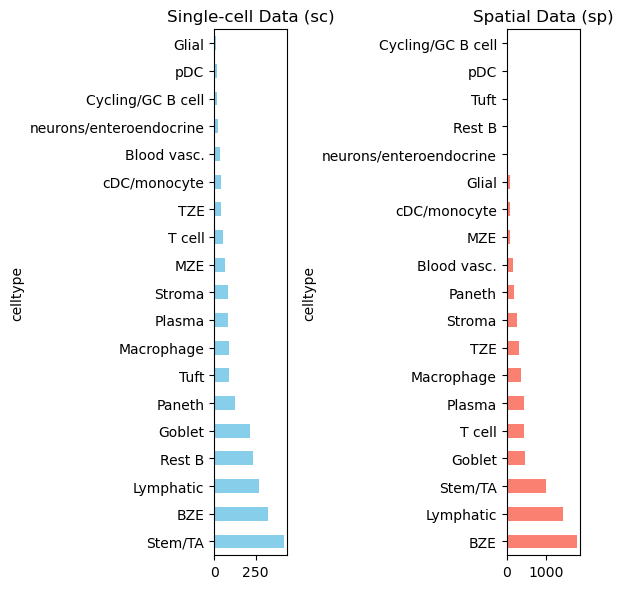

In [8]:
celltypes = np.array(list(set.intersection(set(adata_sp.obs["celltype"]), set(adata_sc.obs["celltype"]))))
fig, axes = plt.subplots(1, 2, figsize=(6, 6))

adata_sc[adata_sc.obs["celltype"].isin(celltypes)].obs["celltype"].value_counts().plot(
    kind="barh", ax=axes[0], color="skyblue"
)
axes[0].set_title("Single-cell Data (sc)")

adata_sp[adata_sp.obs["celltype"].isin(celltypes)].obs["celltype"].value_counts().plot(
    kind="barh", ax=axes[1], color="salmon"
)
axes[1].set_title("Spatial Data (sp)")

plt.tight_layout() 
plt.show()

### Sample from scvi embedding

In [9]:
sampled_expressions = paired_iterator_sampled_expression(
    10,
    a=(adata_sc, model_sc),
    b=(adata_sp, model_sp)
)

### Regular NMF

#### Generate Data

In [ ]:
bar_values = np.array([
    (lambda adata, W, H, _: pearsonr(adata.X.mean(axis=0), (W @ H).mean(axis=0))[0])(
        *(lambda adata: (adata, *non_negative_factorization(adata.X, n_components=3)))(
            (lambda adata, celltype: adata[adata.obs["celltype"] == celltype])(
                adata_sp,
                celltype
            )
        )
    )
    for celltype in celltypes
])

box_values = np.array([
    [
        (lambda adata, W, H, _: pearsonr(adata.X.mean(axis=0), (W @ H).mean(axis=0))[0])(
            *(lambda adata: (adata, *non_negative_factorization(adata.X, n_components=3)))(
                (lambda adata, celltype: adata[adata.obs["celltype"] == celltype])(
                    adata,
                    celltype
                )
            )
        )
        for celltype in celltypes
    ]
    for adata in [paired_expression[1] for paired_expression in sampled_expressions]
])

#### Plotting

/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-

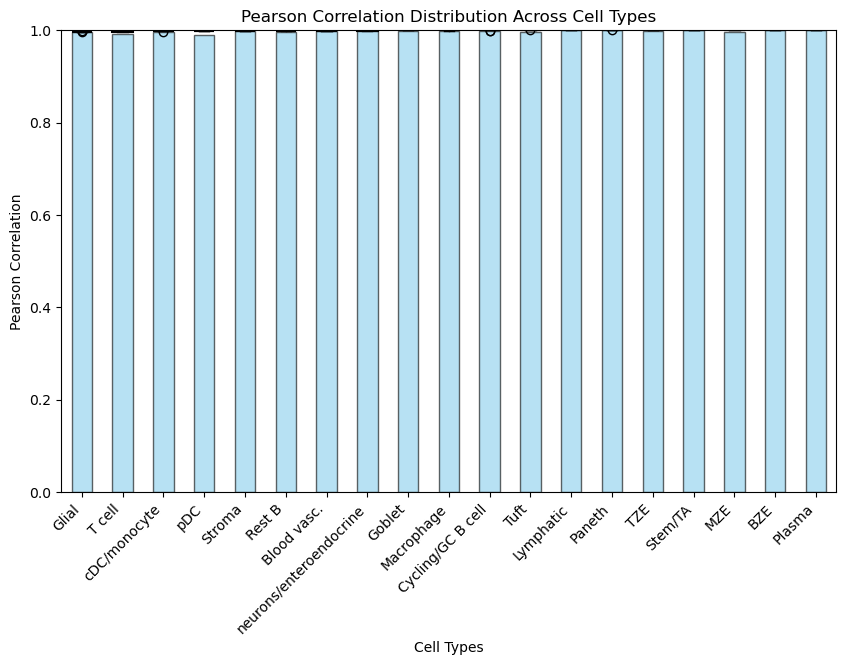

In [11]:

sort_cells = np.argsort(np.median(box_values, axis=0))
bar_values = bar_values[sort_cells]
box_values = box_values[:, sort_cells]
sorted_celltypes = celltypes[sort_cells]

fig, ax = plt.subplots(figsize=(10, 6))
x_positions = np.arange(len(sorted_celltypes)) + 1 

boxprops = dict(facecolor="none", edgecolor="black", linewidth=1.5) 
medianprops = dict(color="black", linewidth=1.5)  
whiskerprops = dict(color="black", linewidth=1) 
capprops = dict(color="black", linewidth=1) 

ax.boxplot(box_values, positions=x_positions, 
           patch_artist=True, 
           boxprops=boxprops, medianprops=medianprops, 
           whiskerprops=whiskerprops, capprops=capprops)

ax.bar(x_positions, bar_values, color="skyblue", alpha=0.6, width=0.5, edgecolor="black")

ax.set_xlabel("Cell Types")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Pearson Correlation Distribution Across Cell Types")
ax.set_xticks(x_positions)
ax.set_xticklabels(sorted_celltypes, rotation=45, ha="right")
ax.set_ylim(0, 1)

plt.show()

### Preinitialised NMF

#### Generate Data

In [ ]:
bar_values = np.array([(lambda adata, W, H, W_init, H_init: pearsonr(adata[:, shared_genes].X.mean(axis=0), (W @ H).mean(axis=0))[0])(
        *(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: (adata_query, *nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, n_components=n_components)))(
            adata_query=adata_sp[adata_sp.obs["celltype"] == celltype],
            adata_reference=adata_sc[adata_sc.obs["celltype"] == celltype],
            shared_genes_mask_reference=shared_genes_mask_sc,
            n_components=8
        )
    ) for celltype in celltypes])

box_values = np.array([[(lambda adata, W, H, W_init, H_init: pearsonr(adata[:, shared_genes].X.mean(axis=0), (W @ H).mean(axis=0))[0])(
        *(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: (adata_query, *nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, n_components=n_components)))(
            adata_query=adata_query[adata_query.obs["celltype"] == celltype],
            adata_reference=adata_reference[adata_reference.obs["celltype"] == celltype],
            shared_genes_mask_reference=shared_genes_mask_sc,
            n_components=8
        )
    ) for celltype in celltypes] for adata_reference, adata_query in sampled_expressions])

#### Plotting

/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-

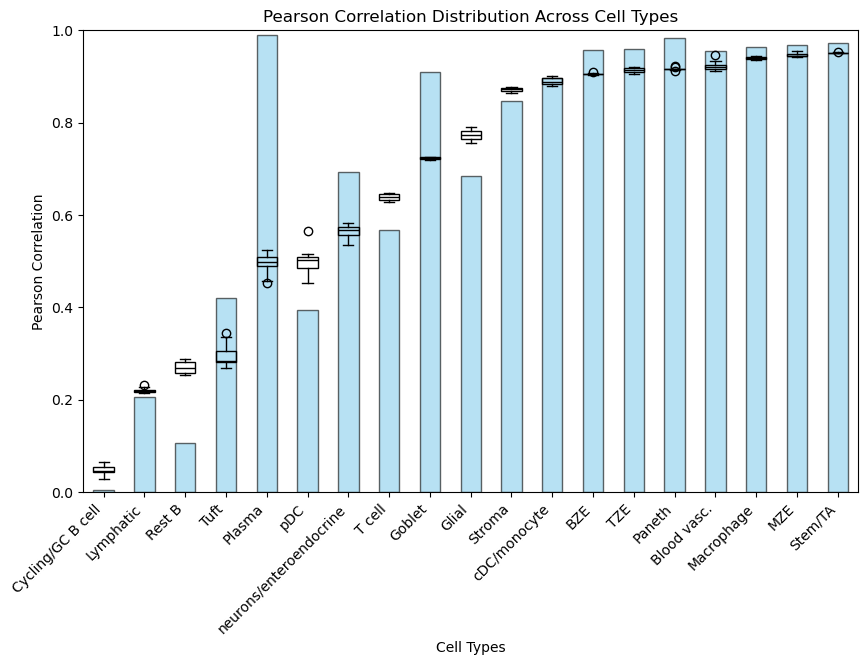

In [60]:
sort_cells = np.argsort(np.median(box_values, axis=0))
bar_values = bar_values[sort_cells]
box_values = box_values[:, sort_cells]
sorted_celltypes = celltypes[sort_cells]

fig, ax = plt.subplots(figsize=(10, 6))
x_positions = (np.arange(len(sorted_celltypes)) + 1)

boxprops = dict(facecolor="none", edgecolor="black", linewidth=1)  
medianprops = dict(color="black", linewidth=1)  
whiskerprops = dict(color="black", linewidth=1)  
capprops = dict(color="black", linewidth=1)  

ax.boxplot(box_values, positions=x_positions, 
           patch_artist=True, 
           boxprops=boxprops, medianprops=medianprops, 
           whiskerprops=whiskerprops, capprops=capprops)

ax.bar(x_positions, bar_values, color="skyblue", alpha=0.6, width=0.5, edgecolor="black")
ax.set_xlabel("Cell Types")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Pearson Correlation Distribution Across Cell Types")
ax.set_xticks(x_positions)
ax.set_xticklabels(sorted_celltypes, rotation=45, ha="right")
ax.set_ylim(0, 1)

plt.show()

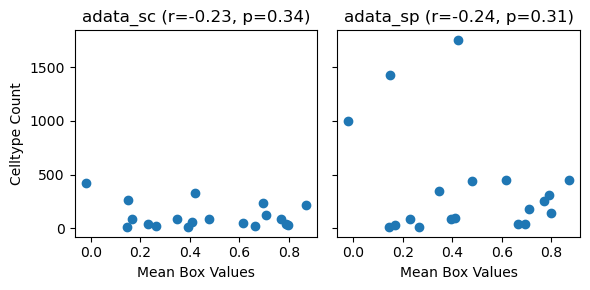

In [141]:
x_values = box_values.mean(axis=0)
y_values_sc = adata_sc.obs["celltype"].value_counts()[celltypes]
y_values_sp = adata_sp.obs["celltype"].value_counts()[celltypes]
r_sc, p_sc = pearsonr(x_values, y_values_sc)
r_sp, p_sp = pearsonr(x_values, y_values_sp)

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

axes[0].scatter(x_values, y_values_sc)
axes[0].set_title(f'adata_sc (r={r_sc:.2f}, p={p_sc:.2g})')
axes[0].set_xlabel("Mean Box Values")
axes[0].set_ylabel("Celltype Count")

axes[1].scatter(x_values, y_values_sp)
axes[1].set_title(f'adata_sp (r={r_sp:.2f}, p={p_sp:.2g})')
axes[1].set_xlabel("Mean Box Values")

plt.tight_layout()
plt.show()

### Preinitialised and masked NMF

#### Generate Data

In [134]:
np.array([(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: pearsonr(
    adata_query[:, shared_genes].X.mean(axis=0), 
    np.hstack([
        (lambda W, H, W_init, H_init, gene_filter_mask: W @ H_init[:, ~gene_filter_mask])(
            *(
                lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: 
                nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, 
                             n_components=n_components, gene_filter_mask=~np.isin(shared_genes, gene)) 
                + (~np.isin(shared_genes, gene),)
            )(adata_query, adata_reference, shared_genes_mask_reference, n_components)
        )
        for gene in shared_genes
    ]).mean(axis=0)
)[0])(
    adata_sp[adata_sp.obs["celltype"] == celltype],
    adata_sc[adata_sc.obs["celltype"] == celltype],
    shared_genes_mask_sc,
    8
) for celltype in ["Stem/TA"]])

/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-

array([0.81793207], dtype=float32)

In [149]:
bar_values = np.array([(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: pearsonr(
    adata_query[:, shared_genes].X.mean(axis=0), 
    np.hstack([
        (lambda W, H, W_init, H_init, gene_filter_mask: W @ H_init[:, ~gene_filter_mask])(
            *(
                lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: 
                nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, 
                             n_components=n_components, gene_filter_mask=~np.isin(shared_genes, gene)) 
                + (~np.isin(shared_genes, gene),)
            )(adata_query, adata_reference, shared_genes_mask_reference, n_components)
        )
        for gene in shared_genes
    ]).mean(axis=0)
)[0])(
    adata_sp[adata_sp.obs["celltype"] == celltype],
    adata_sc[adata_sc.obs["celltype"] == celltype],
    shared_genes_mask_sc,
    8
) for celltype in celltypes])

/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-

In [150]:
box_values = np.array([np.array([(lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: pearsonr(
    adata_query[:, shared_genes].X.mean(axis=0), 
    np.hstack([
        (lambda W, H, W_init, H_init, gene_filter_mask: W @ H_init[:, ~gene_filter_mask])(
            *(
                lambda adata_query, adata_reference, shared_genes_mask_reference, n_components: 
                nmf_transfer(adata_query, adata_reference, shared_genes_mask_reference, 
                             n_components=n_components, gene_filter_mask=~np.isin(shared_genes, gene)) 
                + (~np.isin(shared_genes, gene),)
            )(adata_query, adata_reference, shared_genes_mask_reference, n_components)
        )
        for gene in shared_genes
    ]).mean(axis=0)
)[0])(
    adata_query[adata_query.obs["celltype"] == celltype],
    adata_reference[adata_reference.obs["celltype"] == celltype],
    shared_genes_mask_sc,
    8
) for celltype in celltypes]) for adata_reference, adata_query in sampled_expressions])

/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-packages/sklearn/decomposition/_nmf.py:1742: ConvergenceWarning: Maximum number of iterations 200 reached. Increase it to improve convergence.
  warnings.warn(
/home/gruengroup/christian/mamba_envs/scvi_cuda-env/lib/python3.10/site-

#### plotting

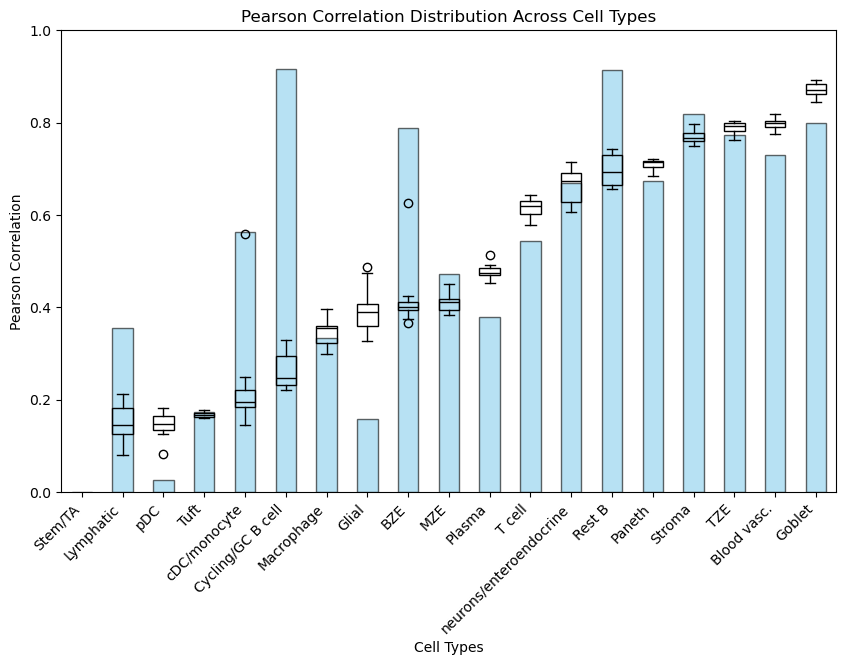

In [ ]:
sort_cells = np.argsort(np.median(box_values, axis=0))

fig, ax = plt.subplots(figsize=(10, 6))
x_positions = (np.arange(len(sorted_celltypes)) + 1)

boxprops = dict(facecolor="none", edgecolor="black", linewidth=1)  
medianprops = dict(color="black", linewidth=1)  
whiskerprops = dict(color="black", linewidth=1)  
capprops = dict(color="black", linewidth=1)  

ax.boxplot(box_values[:, sort_cells], positions=x_positions, 
           patch_artist=True, 
           boxprops=boxprops, medianprops=medianprops, 
           whiskerprops=whiskerprops, capprops=capprops)

ax.bar(x_positions, bar_values[sort_cells], color="skyblue", alpha=0.6, width=0.5, edgecolor="black")
ax.set_xlabel("Cell Types")
ax.set_ylabel("Pearson Correlation")
ax.set_title("Pearson Correlation Distribution Across Cell Types")
ax.set_xticks(x_positions)
ax.set_xticklabels(celltypes[sort_cells], rotation=45, ha="right")
ax.set_ylim(0, 1)

plt.show()

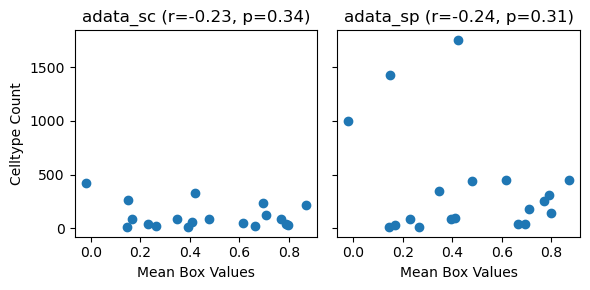

In [142]:
x_values = box_values.mean(axis=0)
y_values_sc = adata_sc.obs["celltype"].value_counts()[celltypes]
y_values_sp = adata_sp.obs["celltype"].value_counts()[celltypes]
r_sc, p_sc = pearsonr(x_values, y_values_sc)
r_sp, p_sp = pearsonr(x_values, y_values_sp)

fig, axes = plt.subplots(1, 2, figsize=(6, 3), sharex=True, sharey=True)

axes[0].scatter(x_values, y_values_sc)
axes[0].set_title(f'adata_sc (r={r_sc:.2f}, p={p_sc:.2g})')
axes[0].set_xlabel("Mean Box Values")
axes[0].set_ylabel("Celltype Count")

axes[1].scatter(x_values, y_values_sp)
axes[1].set_title(f'adata_sp (r={r_sp:.2f}, p={p_sp:.2g})')
axes[1].set_xlabel("Mean Box Values")

plt.tight_layout()
plt.show()